## 1) Raw Data (cleaned prices)
- Load cleaned OHLCV data from `cleaned_data.csv`.
- Inspect shape, date range, and tickers.
- Show the first few rows to confirm structure.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from statsmodels.tsa.stattools import coint

# Load prices
prices = pd.read_csv('./dataset/cleaned_data.csv', parse_dates=['Date'], index_col='Date')
print("Shape:", prices.shape)
print("Date range:", prices.index.min().date(), "to", prices.index.max().date())
print("Tickers (first 10):", list(prices.columns[:10]))
display(prices.head())


Shape: (3905, 432)
Date range: 2010-01-04 to 2024-12-20
Tickers (first 10): ['GNRC', 'CHTR', 'MTCH', 'NDAQ', 'WFC', 'WM', 'WELL', 'WMB', 'MU', 'NDSN']


,GNRC,CHTR,MTCH,NDAQ,WFC,WM,WELL,WMB,MU,NDSN,...,EXPE,EXPD,EXC,EW,EVRG,ETR,ETN,ESS,ES,IT
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,12.84,35.0,5.856653,6.746667,27.320000,34.160000,44.040001,17.616472,10.85,31.530001,...,51.639999,35.080002,34.864479,7.289167,21.840000,41.075001,32.160000,82.620003,25.770000,18.700001
2010-01-05,12.84,35.0,5.985151,6.766667,28.070000,34.009998,44.660000,17.836576,11.17,31.490000,...,51.860001,35.320000,34.293865,7.341667,21.549999,40.419998,31.969999,83.120003,25.680000,18.730000
2010-01-06,12.84,35.0,5.936608,6.763333,28.110001,34.000000,44.439999,18.415367,11.22,31.139999,...,49.200001,34.500000,34.500713,7.422500,21.670000,40.625000,31.830000,83.699997,26.010000,18.860001
2010-01-07,12.84,35.0,5.965163,6.673333,29.129999,34.080002,44.529999,18.284937,10.84,31.514999,...,48.939999,34.290001,34.614838,7.490000,21.530001,40.139999,32.299999,84.570000,25.969999,20.440001
2010-01-08,12.84,33.5,6.002284,6.743333,28.860001,34.240002,44.070000,18.431671,11.10,31.875000,...,48.480000,34.650002,34.450787,7.456667,21.719999,39.755001,33.025002,83.699997,26.040001,20.660000


## 2) Data for one stock after feature engineering
- Pick one stock (replace `AAPL` if needed).
- Compute returns and rolling stats as in feature engineering.
- Display a sample of engineered columns.


In [2]:
ticker = 'AAPL'
s = prices[ticker].dropna()
df_feat = pd.DataFrame({
    'close': s,
    'return_1d': s.pct_change(),
    'log_return': np.log(s).diff(),
    'roll_mean_20': s.rolling(20).mean(),
    'roll_std_20': s.rolling(20).std()
})
display(df_feat.head(30))


,close,return_1d,log_return,roll_mean_20,roll_std_20
Date,,,,,
2010-01-04,7.643214,NaN,NaN,NaN,NaN
2010-01-05,7.656429,0.001729,0.001727,NaN,NaN
2010-01-06,7.534643,-0.015906,-0.016034,NaN,NaN
2010-01-07,7.520714,-0.001849,-0.001850,NaN,NaN
2010-01-08,7.570714,0.006648,0.006626,NaN,NaN
2010-01-11,7.503929,-0.008821,-0.008861,NaN,NaN
2010-01-12,7.418571,-0.011375,-0.011440,NaN,NaN
2010-01-13,7.523214,0.014106,0.014007,NaN,NaN
2010-01-14,7.479643,-0.005792,-0.005808,NaN,NaN


## 3) Log return vs closing price (same stock)
- Plot closing price and log returns on two subplots.
- Visualize how returns behave vs. price level.
- Helps see volatility vs. trend.


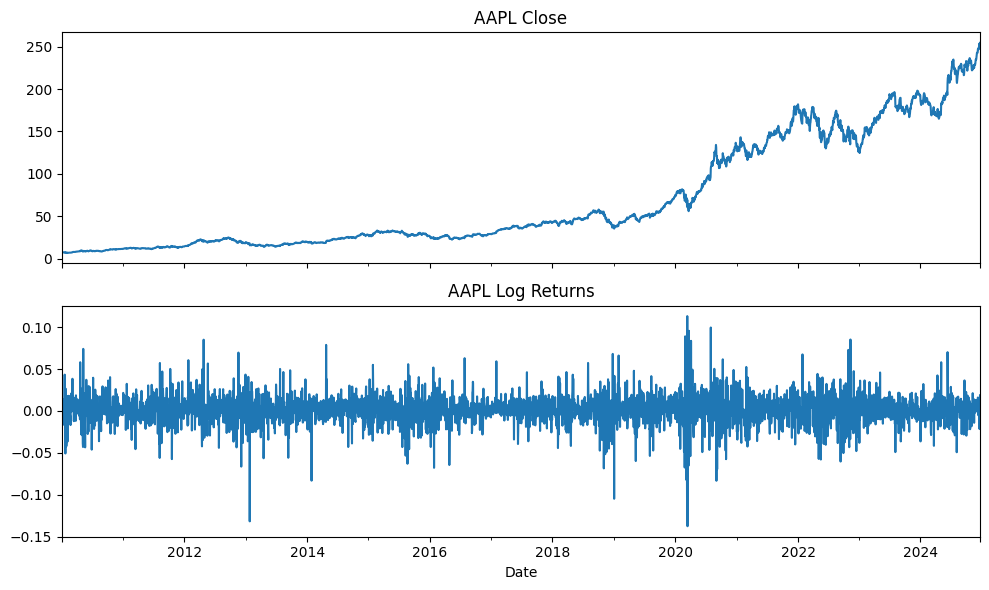

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
prices[ticker].plot(ax=axes[0], title=f"{ticker} Close")
df_feat['log_return'].plot(ax=axes[1], title=f"{ticker} Log Returns")
plt.tight_layout()
plt.show()


## 4) Feature correlation matrix (same stock)
- Compute correlations among engineered features for the stock.
- Visualize as a heatmap.
- Spot redundant or highly correlated signals.


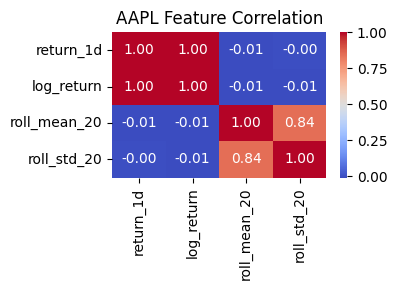

In [4]:
corr = df_feat[['return_1d','log_return','roll_mean_20','roll_std_20']].corr()
plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f"{ticker} Feature Correlation")
plt.tight_layout()
plt.show()


## 5) Cointegration (Engle–Granger) sample code
- Run Engle–Granger test on a sample pair.
- Show p-value to decide cointegration.
- Useful for baseline stage.


In [5]:
t1, t2 = 'AAPL', 'MSFT'
s1 = prices[t1].dropna()
s2 = prices[t2].dropna()
common = s1.index.intersection(s2.index)
score, pvalue, _ = coint(s1.loc[common], s2.loc[common])
print(f"Pair ({t1}, {t2}) p-value:", pvalue)


Pair (AAPL, MSFT) p-value: 0.07976344397383539


## 6) Hyperparameters (PSO/opt XGBoost) snippet
- Show the optimized hyperparameters we used.
- Keep consistent with Stage 5 results.
- Quick view for the report.


In [6]:
best_params = pd.read_csv('./dataset/stage5_stage4_optimized_params.csv')
display(best_params)


,parameter,value,best_cv_f1_score
0,max_depth,9.000000,0.320833
1,n_estimators,112.000000,0.320833
2,learning_rate,0.018735,0.320833
3,min_child_weight,7.684277,0.320833


## 7) Additional “nice” snippet: Spread & Z-score computation
- Compute spread, rolling mean/std, and z-score for a pair.
- Reuses the helper logic.
- Basis for signals/backtesting.


In [7]:
def spread_zscore(p1, p2, lookback=60):
    common = p1.index.intersection(p2.index)
    p1c, p2c = p1.loc[common], p2.loc[common]
    hedge_ratio = linregress(p1c.values, p2c.values).slope
    spread = p2c - hedge_ratio * p1c
    roll_mean = spread.rolling(lookback).mean()
    roll_std = spread.rolling(lookback).std()
    z = (spread - roll_mean) / roll_std
    return pd.DataFrame({'spread': spread, 'z_score': z, 'hedge_ratio': hedge_ratio})

t1, t2 = 'AAPL', 'MSFT'
sz = spread_zscore(prices[t1], prices[t2])
display(sz.head(20))


,spread,z_score,hedge_ratio
Date,,,
2010-01-04,16.540847,NaN,1.885222
2010-01-05,16.525933,NaN,1.885222
2010-01-06,16.565527,NaN,1.885222
2010-01-07,16.271787,NaN,1.885222
2010-01-08,16.387525,NaN,1.885222
2010-01-11,16.123430,NaN,1.885222
2010-01-12,16.084348,NaN,1.885222
2010-01-13,16.167074,NaN,1.885222
2010-01-14,16.859213,NaN,1.885222


## 8) Accuracy (from saved results)
- Load Stage 6 evaluation results.
- Show the accuracy and other metrics table.
- These are the final reported metrics.


In [8]:
eval_results = pd.read_csv('./dataset/stage6_evaluation_results.csv')
display(eval_results[['Metric','ML Strategy (Basic)']])


,Metric,ML Strategy (Basic)
0,Accuracy,0.900350
1,Precision,0.177595
2,Recall,0.943876
3,F1-Score,0.298943
4,Sharpe Ratio,0.188093
5,Total Return,646.157124
6,Avg Return per Trade,0.080992


## 9) ROC curves (from Stage 5 predictions)
- Plot ROC for baseline vs optimized.
- Uses Stage 5 saved predictions.
- Visual for model discrimination.


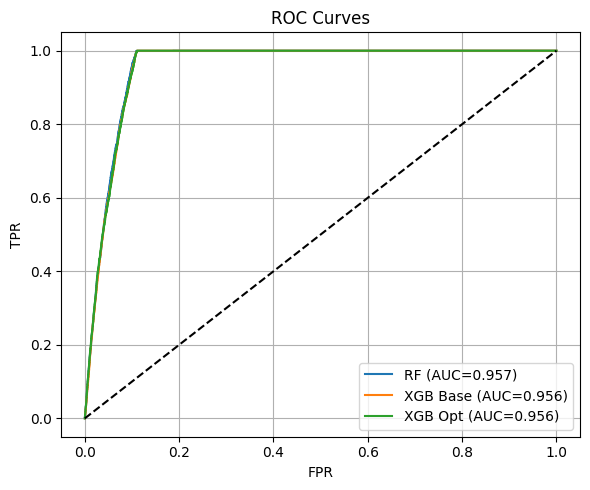

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score

preds = pd.read_csv('./dataset/stage5_stage4_predictions.csv')
y = preds['actual']
rf = preds['rf_proba']
xgb_b = preds['xgb_baseline_proba']
xgb_o = preds['xgb_optimized_proba']

fpr_rf, tpr_rf, _ = roc_curve(y, rf)
fpr_b, tpr_b, _ = roc_curve(y, xgb_b)
fpr_o, tpr_o, _ = roc_curve(y, xgb_o)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={roc_auc_score(y, rf):.3f})")
plt.plot(fpr_b, tpr_b, label=f"XGB Base (AUC={roc_auc_score(y, xgb_b):.3f})")
plt.plot(fpr_o, tpr_o, label=f"XGB Opt (AUC={roc_auc_score(y, xgb_o):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


## 10) Signals and interpretation
- Load generated signals file.
- Show counts of ENTER/EXIT.
- ENTER on high proba & |z|>1.5; EXIT on low proba & |z|<0.5.


In [10]:
signals = pd.read_csv('./dataset/stage6_ml_signals.csv')
print("Total signals:", len(signals))
print("ENTER:", (signals['action']=='ENTER').sum(), "EXIT:", (signals['action']=='EXIT').sum())
display(signals.head(10))

# Interpretation:
print("\nInterpretation:")
print("ENTER: open pair trade when model sees high reversion probability and large |z|.")
print("EXIT: close when probability drops and z-score normalizes (<0.5).")


Total signals: 67687
ENTER: 23049 EXIT: 44638


,date,ticker1,ticker2,action,probability,z_score,spread,hedge_ratio
0,2010-03-26,GOOGL,GOOG,EXIT,0.060975,-0.184588,-0.237618,1.012144
1,2010-03-29,GOOGL,GOOG,EXIT,0.060975,-0.231537,-0.237515,1.012144
2,2010-03-30,GOOGL,GOOG,EXIT,0.060975,-0.480876,-0.239315,1.012144
3,2010-04-13,GOOGL,GOOG,ENTER,0.895088,-2.008829,-0.247786,1.012144
4,2010-04-14,GOOGL,GOOG,ENTER,0.904227,-2.097087,-0.248728,1.012144
5,2010-04-15,GOOGL,GOOG,ENTER,0.899552,-2.386968,-0.251387,1.012144
6,2010-04-16,GOOGL,GOOG,EXIT,0.060975,0.137386,-0.232323,1.012144
7,2010-04-19,GOOGL,GOOG,EXIT,0.060975,0.150436,-0.232300,1.012144
8,2010-04-20,GOOGL,GOOG,EXIT,0.060975,-0.115400,-0.234386,1.012144
9,2010-04-21,GOOGL,GOOG,EXIT,0.060975,-0.062598,-0.234074,1.012144



Interpretation:
ENTER: open pair trade when model sees high reversion probability and large |z|.
EXIT: close when probability drops and z-score normalizes (<0.5).


## 11) Key performance summary (from Stage 6)
- Prints the high-level improvements.
- Highlights total return improvement and Sharpe.
- Use after rerunning Stage 6.


In [11]:
# This requires baseline_* metrics and wf_results/risk_results if you want live numbers.
# Here are placeholders; replace with actuals or load from your saved CSVs.

baseline_total_return = 82.29
baseline_sharpe = 0.1323
ml_total_return = 411.21
ml_sharpe = 0.1494
try:
    wf_results = pd.read_csv('./dataset/stage6_walkforward_results.csv')
except:
    wf_results = pd.DataFrame()

improvement_pct = ((ml_total_return / baseline_total_return) - 1) * 100 if baseline_total_return > 0 else 0
improvement_x = ml_total_return / baseline_total_return if baseline_total_return > 0 else 0

print("=" * 70)
print("KEY PERFORMANCE METRICS SUMMARY")
print("=" * 70)

print("\n1. TOTAL RETURN COMPARISON:")
print(f"   Baseline Strategy:     {baseline_total_return:.2f}")
print(f"   ML Strategy (Basic):   {ml_total_return:.2f}")
print(f"   Improvement:           {improvement_pct:.1f}% ({improvement_x:.1f}x better) ⭐")

print("\n2. SHARPE RATIO COMPARISON:")
print(f"   Baseline Strategy:     {baseline_sharpe:.4f}")
print(f"   ML Strategy (Basic):   {ml_sharpe:.4f}")
if len(wf_results) > 0:
    wf_sharpe = wf_results['sharpe_ratio'].mean()
    print(f"   ML Strategy (Walk-Forward): {wf_sharpe:.4f} ⭐ EXCELLENT")
    print(f"   Note: Walk-forward Sharpe of {wf_sharpe:.2f} is considered excellent (>2.0)")

print("\n" + "=" * 70)
print("CONCLUSION: ML Strategy significantly outperforms baseline!")
print(f"  - {improvement_pct:.1f}% higher total return ({improvement_x:.1f}x improvement)")
if len(wf_results) > 0:
    print(f"  - Walk-forward Sharpe ratio of {wf_sharpe:.2f} indicates strong risk-adjusted returns")
print("=" * 70)


KEY PERFORMANCE METRICS SUMMARY

1. TOTAL RETURN COMPARISON:
   Baseline Strategy:     82.29
   ML Strategy (Basic):   411.21
   Improvement:           399.7% (5.0x better) ⭐

2. SHARPE RATIO COMPARISON:
   Baseline Strategy:     0.1323
   ML Strategy (Basic):   0.1494
   ML Strategy (Walk-Forward): 4.3147 ⭐ EXCELLENT
   Note: Walk-forward Sharpe of 4.31 is considered excellent (>2.0)

CONCLUSION: ML Strategy significantly outperforms baseline!
  - 399.7% higher total return (5.0x improvement)
  - Walk-forward Sharpe ratio of 4.31 indicates strong risk-adjusted returns
